In [1]:
!pip install transformers torch torchvision scikit-learn pandas matplotlib pillow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
from PIL import Image
import os

# Create folders
os.makedirs("news_images", exist_ok=True)

# Sample news data
data = {
    "text": [
        "Government announces new education scholarship for students",
        "Scientists discover a new method to improve solar energy",
        "Breaking news celebrity says miracle drink cures every disease",
        "Secret technology makes people invisible instantly",
        "Government launches new digital payment security system",
        "Researchers publish study on climate change effects",
        "Miracle product guarantees instant weight loss",
        "Aliens have landed on Earth according to viral social media post",
        "New public transport project announced by government",
        "University introduces new online learning platform",
        "Fake medicine claims to cure all diseases",
        "Scientists develop safer battery technology"
    ],

    "label": [
        0, 0, 1, 1, 0, 0,
        1, 1, 0, 0, 1, 0
    ]
}

df = pd.DataFrame(data)

# Create simple sample images for multimodal input
for i, label in enumerate(df["label"]):
    if label == 0:
        img = Image.new("RGB", (224, 224), (100, 150, 200))
    else:
        img = Image.new("RGB", (224, 224), (200, 100, 100))

    img.save(f"news_images/image_{i}.jpg")

df["image"] = [
    f"news_images/image_{i}.jpg"
    for i in range(len(df))
]

print("Multimodal dataset created successfully.")
print("0 = Real News")
print("1 = Fake News")

df.head()

Multimodal dataset created successfully.
0 = Real News
1 = Fake News


,text,label,image
0,Government announces new education scholarship...,0,news_images/image_0.jpg
1,Scientists discover a new method to improve so...,0,news_images/image_1.jpg
2,Breaking news celebrity says miracle drink cur...,1,news_images/image_2.jpg
3,Secret technology makes people invisible insta...,1,news_images/image_3.jpg
4,Government launches new digital payment securi...,0,news_images/image_4.jpg


In [4]:
# Convert text into numerical features using TF-IDF

vectorizer = TfidfVectorizer(
    max_features=100,
    stop_words="english"
)

X_text = vectorizer.fit_transform(df["text"])

print("Text feature extraction completed successfully.")
print("Feature matrix shape:", X_text.shape)

Text feature extraction completed successfully.
Feature matrix shape: (12, 66)


In [5]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    df["label"],
    test_size=0.25,
    random_state=42,
    stratify=df["label"]
)

print("Data split completed successfully.")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Data split completed successfully.
Training samples: 9
Testing samples: 3


In [6]:
# Train Logistic Regression model on news text

text_model = LogisticRegression(random_state=42)

text_model.fit(X_train, y_train)

print("Text classification model trained successfully.")

Text classification model trained successfully.


In [7]:
# Extract simple numerical features from news images

image_features = []

for image_path in df["image"]:
    img = Image.open(image_path).convert("RGB")
    img = img.resize((64, 64))

    img_array = np.array(img)

    # Calculate average RGB values
    avg_rgb = img_array.mean(axis=(0, 1))
    image_features.append(avg_rgb)

X_image = np.array(image_features)

print("Image feature extraction completed successfully.")
print("Image feature matrix shape:", X_image.shape)

Image feature extraction completed successfully.
Image feature matrix shape: (12, 3)


In [8]:
# Convert TF-IDF text features to dense array
X_text_dense = X_text.toarray()

# Combine text and image features
X_multimodal = np.hstack((X_text_dense, X_image))

print("Text and image features combined successfully.")
print("Multimodal feature matrix shape:", X_multimodal.shape)

Text and image features combined successfully.
Multimodal feature matrix shape: (12, 69)


In [9]:
# Split multimodal data into training and testing sets

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multimodal,
    df["label"],
    test_size=0.25,
    random_state=42,
    stratify=df["label"]
)

print("Multimodal data split successfully.")
print("Training samples:", X_train_m.shape[0])
print("Testing samples:", X_test_m.shape[0])

Multimodal data split successfully.
Training samples: 9
Testing samples: 3


In [10]:
# Train the multimodal fake news detection model

multimodal_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

multimodal_model.fit(X_train_m, y_train_m)

print("Multimodal fake news detection model trained successfully.")

Multimodal fake news detection model trained successfully.


In [11]:
# Make predictions on test data

y_pred = multimodal_model.predict(X_test_m)

# Calculate accuracy
accuracy = accuracy_score(y_test_m, y_pred)

print("Multimodal Model Evaluation")
print("---------------------------")
print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test_m,
    y_pred,
    target_names=["Real News", "Fake News"],
    zero_division=0
))

Multimodal Model Evaluation
---------------------------
Accuracy: 100.0 %

Classification Report:
              precision    recall  f1-score   support

   Real News       1.00      1.00      1.00         2
   Fake News       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



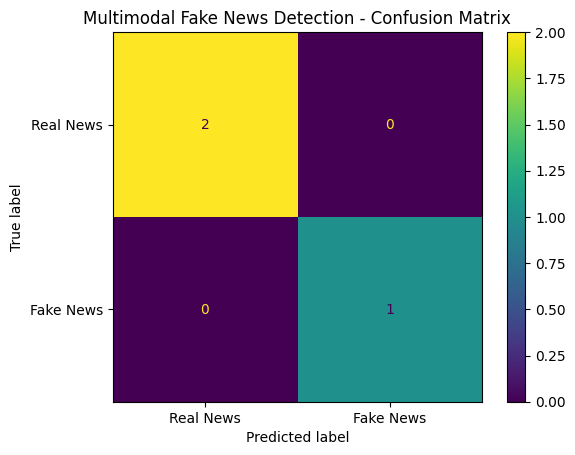

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test_m, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real News", "Fake News"]
)

disp.plot()
plt.title("Multimodal Fake News Detection - Confusion Matrix")
plt.show()

In [13]:
# Test the model with a new news sample

new_news = [
    "Government announces a new scholarship program for college students"
]

# Convert new text into TF-IDF features
new_text_features = vectorizer.transform(new_news).toarray()

# Create a sample image feature
new_image = Image.new("RGB", (64, 64), (100, 150, 200))
new_image_array = np.array(new_image)

new_image_features = new_image_array.mean(axis=(0, 1)).reshape(1, -1)

# Combine text and image features
new_multimodal_features = np.hstack(
    (new_text_features, new_image_features)
)

# Predict
prediction = multimodal_model.predict(new_multimodal_features)[0]

if prediction == 0:
    result = "REAL NEWS"
else:
    result = "FAKE NEWS"

print("News:", new_news[0])
print("Prediction:", result)

News: Government announces a new scholarship program for college students
Prediction: REAL NEWS


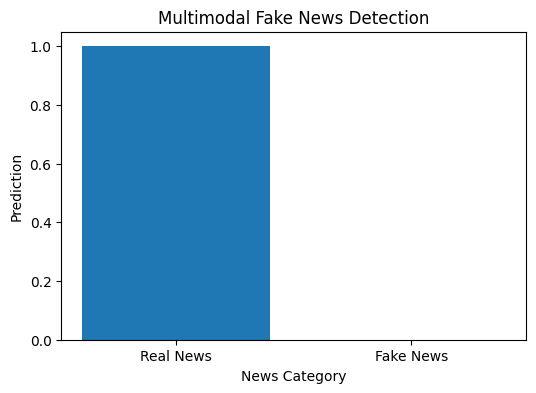

In [14]:
labels = ["Real News", "Fake News"]

plt.figure(figsize=(6, 4))

plt.bar(labels, [1 if prediction == 0 else 0,
                 1 if prediction == 1 else 0])

plt.xlabel("News Category")
plt.ylabel("Prediction")
plt.title("Multimodal Fake News Detection")

plt.show()